In [4]:

import numpy as np
x_train = np.array([1.0, 2.0])   #features
y_train = np.array([300.0, 500.0]) #target values

In [5]:
print(x_train)
print(y_train)
print(x_train[0])
print(x_train[1])
print(x_train.shape)
print(y_train.shape)

[1. 2.]
[300. 500.]
1.0
2.0
(2,)
(2,)


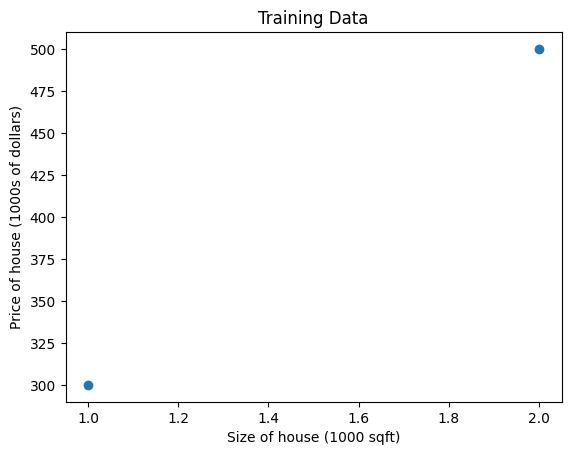

In [6]:
import matplotlib.pyplot as plt
plt.scatter(x_train, y_train)
plt.title("Training Data")
plt.xlabel("Size of house (1000 sqft)")
plt.ylabel("Price of house (1000s of dollars)")
plt.show()

In [7]:
#Create linear regression model f(x) = wx + b
def predict(x, w, b):
    return w * x + b

In [8]:
#Guessing with random values to find the parameter
w = 100
b = 100

y_pred = predict(x_train, w, b)

print("Predictions:", y_pred)
print("Actual:", y_train)

Predictions: [200. 300.]
Actual: [300. 500.]


In [9]:
#adding more data points to the training set
x_train = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_train = np.array([300.0, 500.0, 700.0, 900.0, 1100.0])

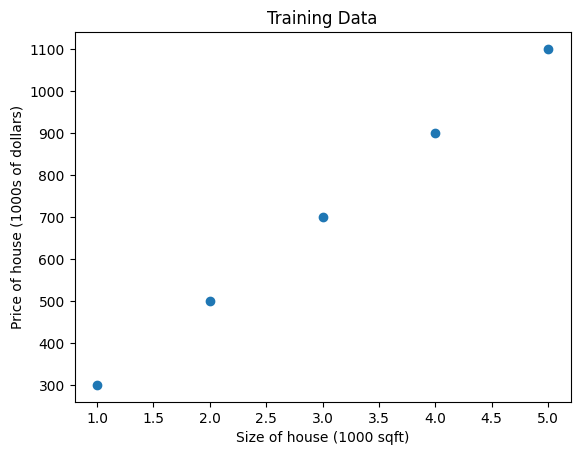

In [10]:
plt.scatter(x_train, y_train)
plt.title("Training Data")
plt.xlabel("Size of house (1000 sqft)")
plt.ylabel("Price of house (1000s of dollars)")
plt.show()

In [11]:
y_pred = predict(x_train, w, b)
print("Predictions:", y_pred)
print("Actual:", y_train)

Predictions: [200. 300. 400. 500. 600.]
Actual: [ 300.  500.  700.  900. 1100.]


In [12]:
#Cost function
def compute_cost(x, y, w, b):

    m = x.shape[0] #number of training examples
    cost = 0

    for i in range(m):
        f_wb = w * x[i] + b 
        cost += (f_wb - y[i]) ** 2

    total_cost = 1 / (2 * m) * cost

    return total_cost

In [13]:
#function to calculate the partial derivatives of the cost function with respect to w and b
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw += (f_wb - y[i]) * x[i]
        dj_db += (f_wb - y[i])

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db



In [1]:
#function to run gradient descent
def gradient_descent(x, y, w, b, alpha, iterations):
    cost_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost:.2f}")

    return w, b, cost_history

In [14]:
w = 0
b = 0
alpha = 0.01
iterations = 1000

w, b, cost_history = gradient_descent(x_train, y_train, w, b, alpha, iterations)

print("Final w:", w)
print("Final b:", b)

Iteration 0: Cost 221587.00
Iteration 100: Cost 110.96
Iteration 200: Cost 79.11
Iteration 300: Cost 56.40
Iteration 400: Cost 40.21
Iteration 500: Cost 28.67
Iteration 600: Cost 20.44
Iteration 700: Cost 14.57
Iteration 800: Cost 10.39
Iteration 900: Cost 7.40
Final w: 202.11314863929584
Final b: 92.37086291370957


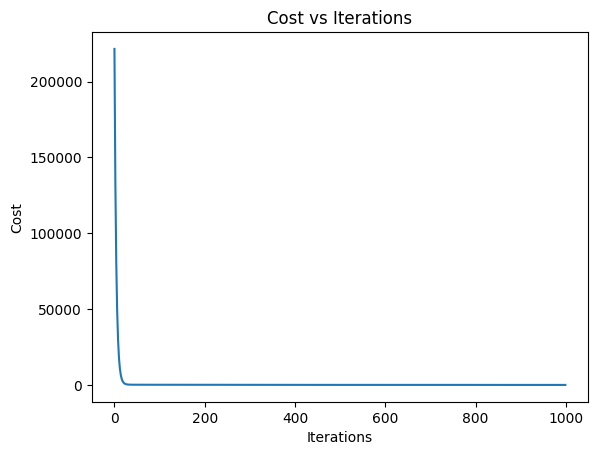

In [15]:
plt.plot(cost_history)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

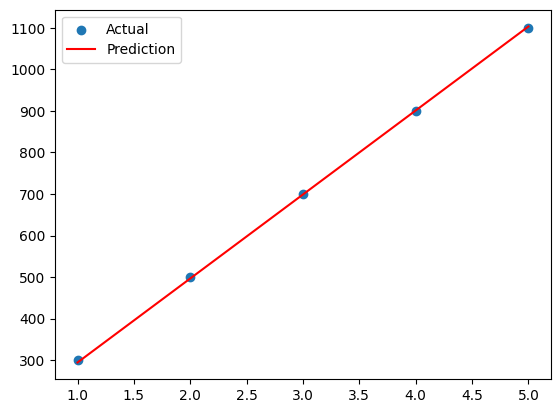

In [16]:
y_pred = predict(x_train, w, b)

plt.scatter(x_train, y_train, label="Actual")
plt.plot(x_train, y_pred, color="red", label="Prediction")
plt.legend()
plt.show()